**Max Begun**

In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("timmate/avocado-prices-2020")

print("Path to dataset files:", path)

# Read the CSV
df = pd.read_csv(path + "/avocado-updated-2020.csv")

df.head()

Path to dataset files: C:\Users\mbbeg\.cache\kagglehub\datasets\timmate\avocado-prices-2020\versions\2


,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington


In [2]:
df.describe()

,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year
count,33045.000000,3.304500e+04,3.304500e+04,3.304500e+04,3.304500e+04,3.304500e+04,3.304500e+04,3.304500e+04,3.304500e+04,33045.000000
mean,1.379941,9.683997e+05,3.023914e+05,2.797693e+05,2.148255e+04,3.646735e+05,2.501980e+05,1.067329e+05,7.742585e+03,2017.460887
std,0.378972,3.934533e+06,1.301026e+06,1.151052e+06,1.001607e+05,1.564004e+06,1.037734e+06,5.167226e+05,4.819803e+04,1.699747
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2015.000000
25%,1.100000,1.511895e+04,7.673100e+02,2.712470e+03,0.000000e+00,9.121860e+03,6.478630e+03,4.662900e+02,0.000000e+00,2016.000000
50%,1.350000,1.291170e+05,1.099477e+04,2.343600e+04,1.780900e+02,5.322224e+04,3.687699e+04,6.375860e+03,0.000000e+00,2017.000000
75%,1.620000,5.058285e+05,1.190219e+05,1.352389e+05,5.096530e+03,1.744314e+05,1.206624e+05,4.041723e+04,8.044400e+02,2019.000000
max,3.250000,6.371614e+07,2.274362e+07,2.047057e+07,2.546439e+06,3.168919e+07,2.055041e+07,1.332760e+07,1.403184e+06,2020.000000


The data set contains 33,045 observations. The average avocado price is about $1.38, with prices ranging from $0.44 to $3.25. The average total sales volume is about 968,400 avocados, although sales vary greatly across observations. The data also includes sales for different avocado PLU codes, bag sizes, and years from 2015 to 2020.


In [3]:

avocado_clean = df.copy()
avocado_clean["date"] = pd.to_datetime(avocado_clean["date"])

# Rename the PLU columns
avocado_clean = avocado_clean.rename(columns={
    "4046": "small_hass",
    "4225": "large_hass",
    "4770": "xlarge_hass"
})

avocado_clean = avocado_clean.drop_duplicates()
avocado_clean.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington


In [4]:
# Keep only organic avocados from 2017
organic_2017 = avocado_clean[(avocado_clean["year"] == 2017) & (avocado_clean["type"] == "organic")]
organic_2017.groupby("geography")["small_hass"].sum().sort_values(ascending=False)

geography
Total U.S.              6882024.42
West                    1870206.29
South Central           1717104.19
California              1526290.58
Northeast                925832.36
Los Angeles              600718.66
New York                 599671.34
Denver                   556346.10
Houston                  498024.65
San Francisco            458478.55
Dallas/Ft. Worth         373197.18
Southeast                285124.34
Great Lakes              202487.68
Midsouth                 186395.50
Phoenix/Tucson           184084.38
Portland                 176110.47
Plains                   168583.40
Philadelphia             155009.91
Sacramento               112551.40
West Tex/New Mexico      110910.95
Las Vegas                 84601.96
Baltimore/Washington      73689.77
San Diego                 68489.39
Seattle                   63564.50
Orlando                   47517.68
Pittsburgh                47144.23
Atlanta                   46000.79
St. Louis                 45372.15
Columbus  

The Western region sold the most small Hass Avocados.

In [5]:
# Split date into month, day, and year
avocado_clean["month"] = avocado_clean["date"].dt.month
avocado_clean["day"] = avocado_clean["date"].dt.day
avocado_clean["year"] = avocado_clean["date"].dt.year


monthly_volume = avocado_clean.groupby("month")["total_volume"].mean()
monthly_volume.sort_values(ascending=False)

month
5     1.123632e+06
2     1.095374e+06
6     1.051247e+06
4     1.016582e+06
3     9.957150e+05
1     9.853122e+05
7     9.832681e+05
8     9.499249e+05
9     9.064773e+05
10    8.446863e+05
11    8.223470e+05
12    8.076695e+05
Name: total_volume, dtype: float64

May had the most Avocado Sales across the years of the df.

geography
Los Angeles         1.567566e+06
New York            8.631458e+05
Dallas/Ft. Worth    7.127519e+05
Houston             6.876533e+05
Phoenix/Tucson      6.250383e+05
Name: total_volume, dtype: float64


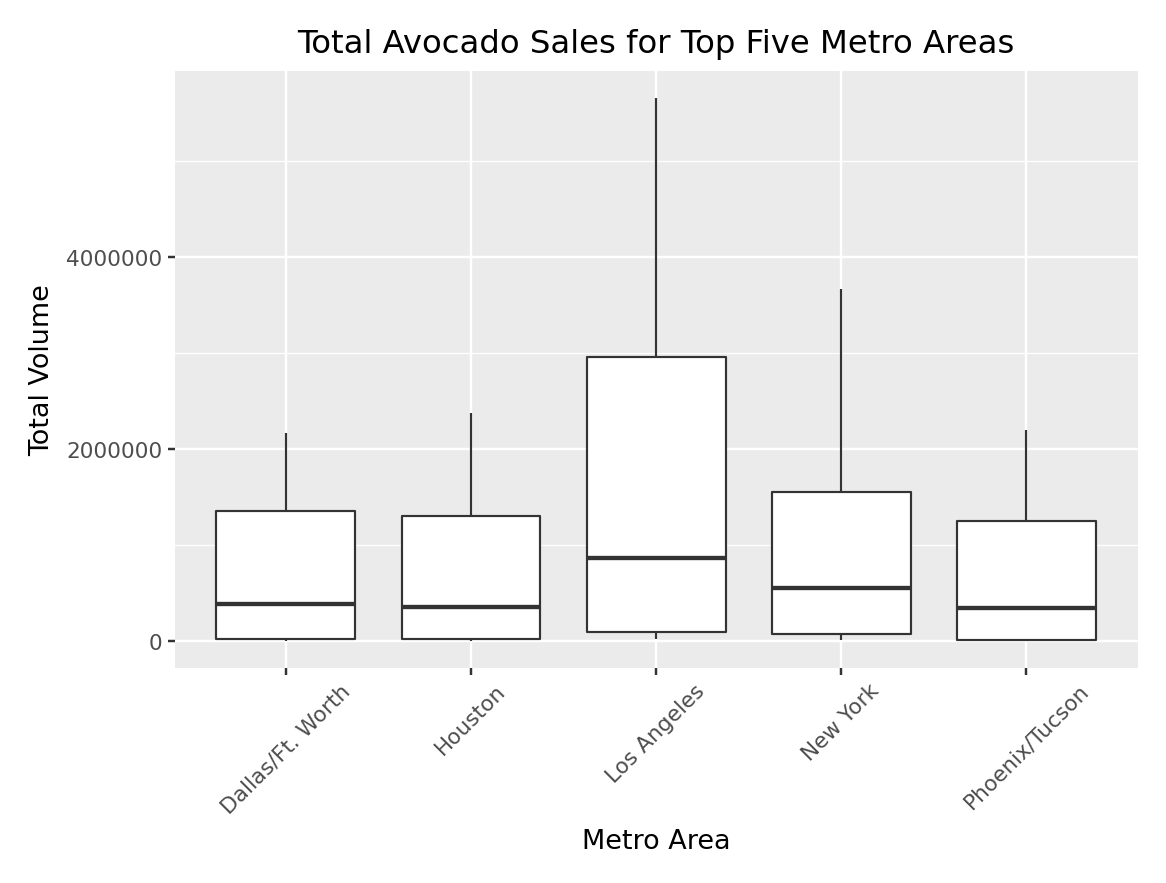

In [6]:
from plotnine import ggplot, aes, geom_boxplot, labs, theme, element_text

not_metro = ["Total U.S.","West","Southeast","South Central","Plains","Midsouth","Northeast","Great Lakes","Northern New England","California"]
metro = avocado_clean[~avocado_clean["geography"].isin(not_metro)]

# Find the top 5 metro areas by average total volume
top_five = (metro.groupby("geography")["total_volume"].mean().sort_values(ascending=False).head(5))
print(top_five)

# Keep only the top 5 metro areas
top_five_data = metro[metro["geography"].isin(top_five.index)]

# Create boxplot
(ggplot(top_five_data, aes(x="geography", y="total_volume"))+ geom_boxplot()+ labs(x="Metro Area", y="Total Volume", title="Total Avocado Sales for Top Five Metro Areas")
    + theme(axis_text_x=element_text(rotation=45)))

In [7]:
california_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

california = avocado_clean[avocado_clean["geography"].isin(california_regions)]

california.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,month,day
44,2015-01-04,0.85,2682159.95,1837999.65,524430.47,64225.78,255504.05,215571.80,36981.72,2950.53,conventional,2015,Los Angeles,1,4
45,2015-01-04,1.25,54495.54,47721.51,1723.40,0.00,5050.63,5050.63,0.00,0.00,organic,2015,Los Angeles,1,4
80,2015-01-04,1.05,430138.88,110693.69,270107.61,9737.50,39600.08,39600.08,0.00,0.00,conventional,2015,Sacramento,1,4
81,2015-01-04,1.33,9213.49,3727.52,4327.52,0.00,1158.45,1158.45,0.00,0.00,organic,2015,Sacramento,1,4
82,2015-01-04,0.94,461607.33,244152.26,165299.33,15302.75,36852.99,30884.29,5595.00,373.70,conventional,2015,San Diego,1,4


In [8]:
price_summary = california.groupby(["geography", "type"])["average_price"].mean()

price_summary

price_diff = california.groupby(["geography", "type"])["average_price"].mean().unstack()

price_diff["difference"] = price_diff["organic"] - price_diff["conventional"]

price_diff


type,conventional,organic,difference
geography,,,
Los Angeles,1.047124,1.574902,0.527778
Sacramento,1.295359,1.873856,0.578497
San Diego,1.113856,1.798366,0.684510
San Francisco,1.400490,2.119444,0.718954


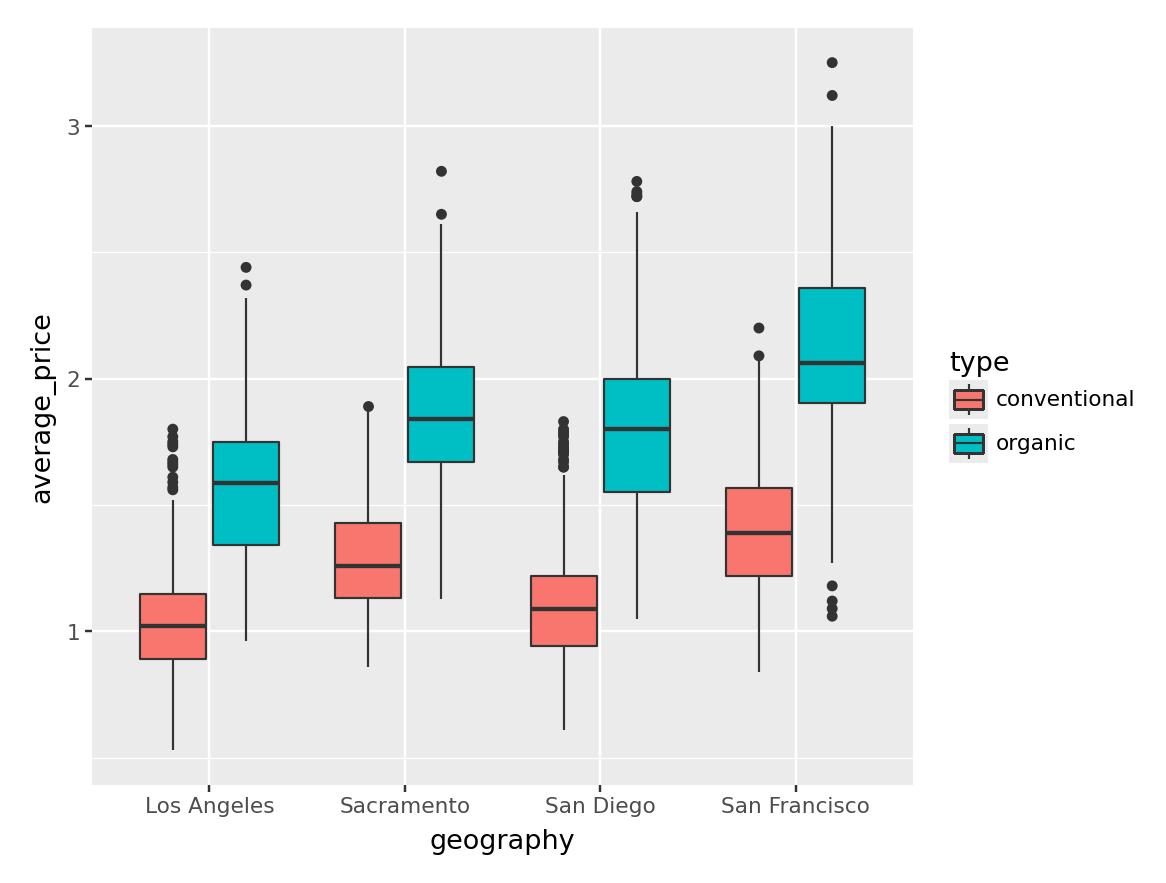

In [9]:
from plotnine import *

ggplot(california, aes(x="geography", y="average_price", fill="type")) + geom_boxplot()


In SF and SD are the price differences most extreme.

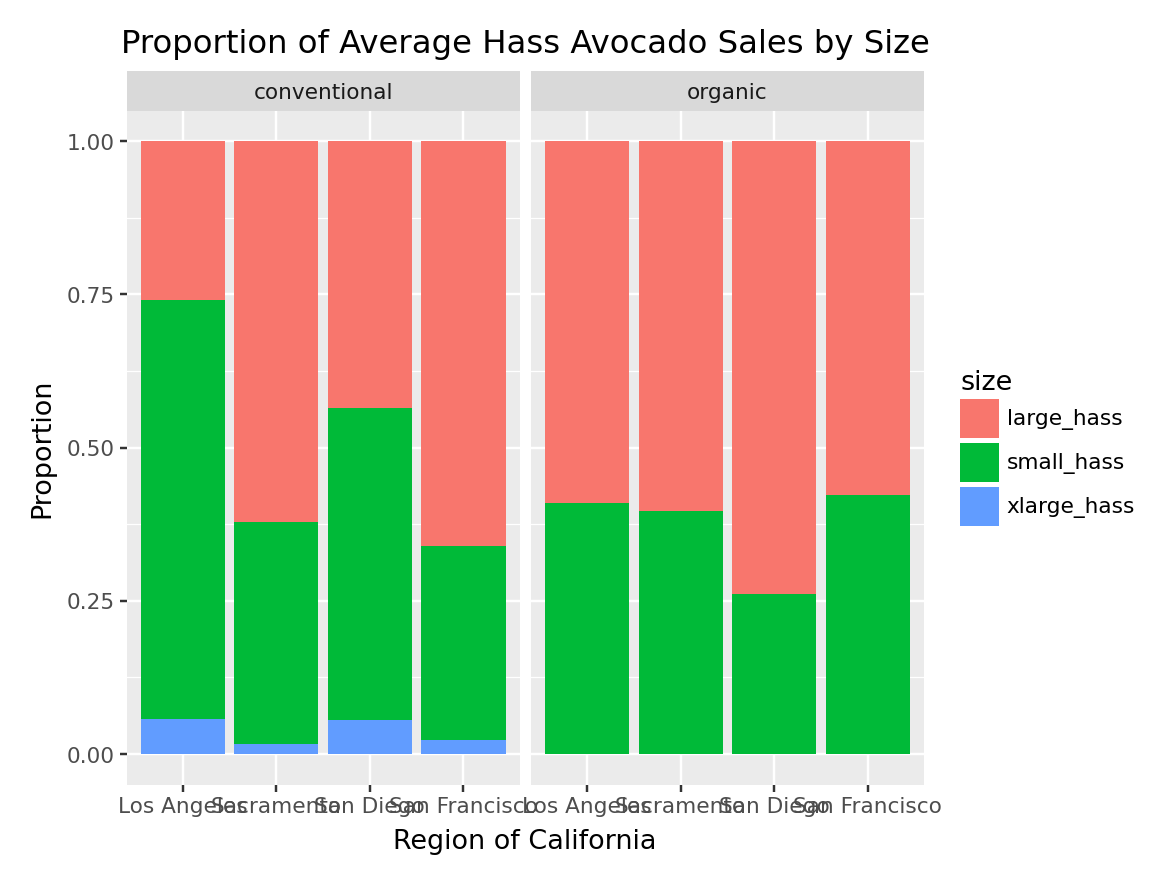

In [10]:
avocado_sizes = california.groupby(["geography", "type"])[["small_hass", "large_hass", "xlarge_hass"]].mean().reset_index()

avocado_sizes = avocado_sizes.melt(id_vars=["geography", "type"], var_name="size", value_name="average_sales")

ggplot(avocado_sizes, aes(x="geography", y="average_sales", fill="size")) + geom_col(position="fill") + facet_wrap("type") + labs(x="Region of California", y="Proportion", title="Proportion of Average Hass Avocado Sales by Size")

***EXPANDED***

In [11]:
# Download housing data
housing_path = kagglehub.dataset_download("zhenyufan/zillow-housing-price")

# Read the CSV
housing = pd.read_csv(housing_path + "/Zillow Single Family Residence.csv")

housing.head()

,Unnamed: 0,RegionID,RegionName,City,State,Metro,CountyName,SizeRank,1996-04,1996-05,...,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12
0,0,84654,60657,Chicago,IL,Chicago-Naperville-Elgin,Cook County,1,334200.0,335400.0,...,1037400,1038700,1041500,1042800,1042900,1044400,1047800,1049700,1048300,1047900
1,1,91982,77494,Katy,TX,Houston-The Woodlands-Sugar Land,Harris County,2,210400.0,212200.0,...,330400,332700,334500,335900,337000,338300,338400,336900,336000,336500
2,2,84616,60614,Chicago,IL,Chicago-Naperville-Elgin,Cook County,3,498100.0,500900.0,...,1317900,1321100,1325300,1323800,1321200,1320700,1319500,1318800,1319700,1323300
3,3,93144,79936,El Paso,TX,El Paso,El Paso County,4,77300.0,77300.0,...,120800,121300,122200,123000,123600,124500,125600,126300,126800,127400
4,4,91940,77449,Katy,TX,Houston-The Woodlands-Sugar Land,Harris County,5,95400.0,95600.0,...,175500,176400,176900,176900,177300,178000,178500,179300,180200,180700


In [12]:
# Keep the four California regions
california_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

housing_ca = housing[
    (housing["State"] == "CA") &
    (housing["City"].isin(california_regions))
]

housing_ca.head()

,Unnamed: 0,RegionID,RegionName,City,State,Metro,CountyName,SizeRank,1996-04,1996-05,...,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12
9,9,97564,94109,San Francisco,CA,San Francisco-Oakland-Hayward,San Francisco County,10,766000.0,771100.0,...,3761200,3810600,3876700,3942300,3982900,3993000,3999000,4014600,4009500,4016600
32,32,96027,90046,Los Angeles,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,33,340600.0,341700.0,...,1932400,1935400,1941500,1948700,1938000,1916500,1899600,1894800,1892600,1893500
79,79,97565,94110,San Francisco,CA,San Francisco-Oakland-Hayward,San Francisco County,80,213900.0,214800.0,...,1566500,1592600,1625200,1645500,1651200,1653600,1656100,1654100,1643000,1637100
81,81,96015,90034,Los Angeles,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,82,231300.0,231700.0,...,1409200,1417600,1422100,1423900,1424600,1428400,1432300,1432200,1419600,1407400
92,92,96025,90044,Los Angeles,CA,Los Angeles-Long Beach-Anaheim,Los Angeles County,93,119500.0,119500.0,...,416300,418200,419200,419800,420700,422600,424900,426700,427700,428500


In [13]:
# Reshape the housing prices
date_cols = housing_ca.loc[:, "2015-01":].columns

housing_long = housing_ca.melt(
    id_vars=["City"],
    value_vars=date_cols,
    var_name="date",
    value_name="house_price"
)

housing_long["date"] = pd.to_datetime(housing_long["date"])
housing_long["month"] = housing_long["date"].dt.to_period("M")

# Average the different homes/ZIP codes within each city
housing_long = housing_long.groupby(
    ["City", "month"]
)["house_price"].mean().reset_index()

housing_long = housing_long.rename(columns={"City": "geography"})

housing_long.head()

,geography,month,house_price
0,Los Angeles,2015-01,771312.765957
1,Los Angeles,2015-02,779776.595745
2,Los Angeles,2015-03,786850.000000
3,Los Angeles,2015-04,793780.851064
4,Los Angeles,2015-05,800252.127660


In [14]:
# Make avocado data monthly and join the data sets
california_monthly = california.copy()

california_monthly["month"] = california_monthly["date"].dt.to_period("M")

california_monthly = california_monthly.groupby(
    ["geography", "month"]
).agg(
    average_price=("average_price", "mean"),
    total_volume=("total_volume", "sum")
).reset_index()

california_joined = california_monthly.merge(
    housing_long,
    on=["geography", "month"],
    how="inner"
)

california_joined.head()

,geography,month,average_price,total_volume,house_price
0,Los Angeles,2015-01,1.05000,10722981.70,771312.765957
1,Los Angeles,2015-02,1.06250,12737718.71,779776.595745
2,Los Angeles,2015-03,1.11400,13827450.28,786850.000000
3,Los Angeles,2015-04,1.18875,10836845.74,793780.851064
4,Los Angeles,2015-05,1.13400,16400578.36,800252.127660


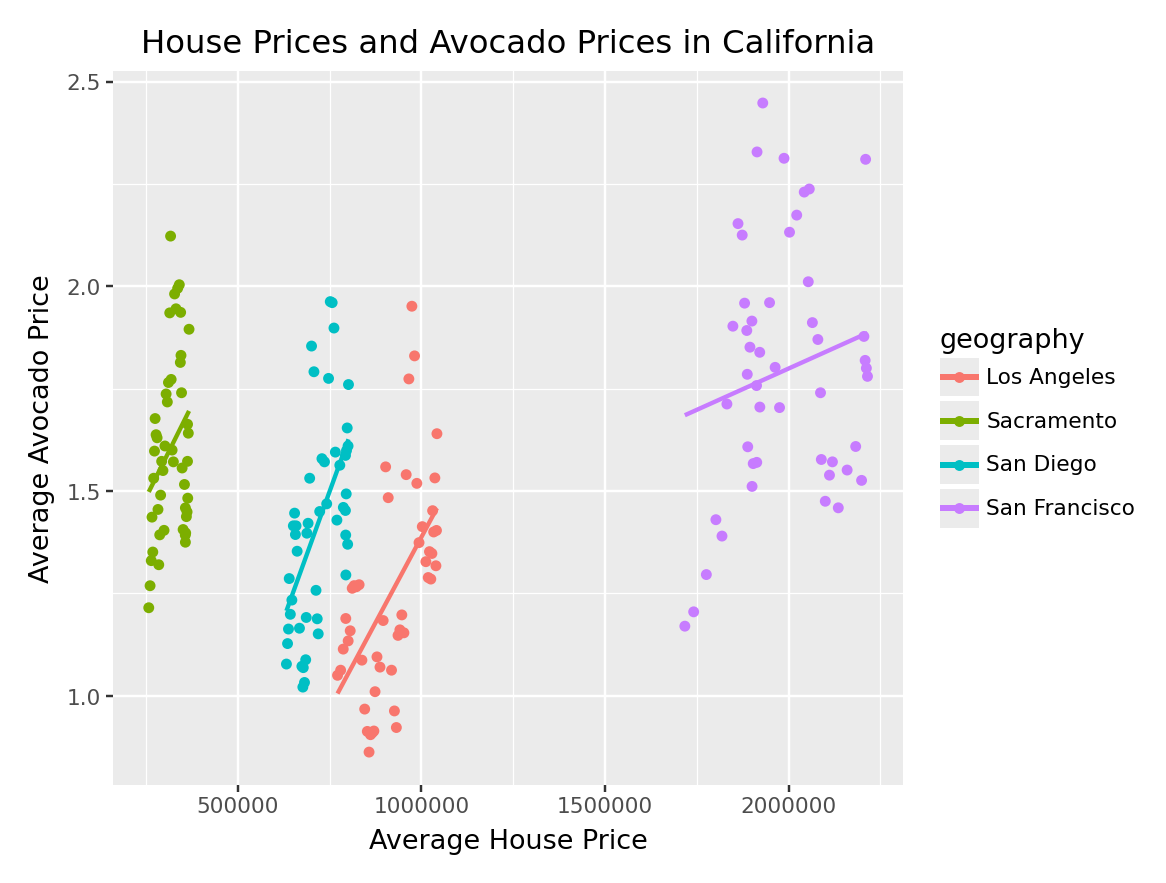

In [15]:
# Plot house prices and avocado prices
ggplot(
    california_joined,
    aes(x="house_price", y="average_price", color="geography")
) + geom_point() + geom_smooth(method="lm", se=False) + labs(
    x="Average House Price",
    y="Average Avocado Price",
    title="House Prices and Avocado Prices in California"
)

The plot suggests a positive relationship between house prices and avocado prices in these four California regions. Within most regions, avocado prices tend to increase as house prices increase. San Francisco has by far the highest house prices and also generally has higher avocado prices, while Los Angeles and San Diego show fairly clear positive trends over time. However, the relationship is not perfect across all regions, since Sacramento has relatively low house prices but avocado prices that overlap with the other cities. Overall, the data suggests that higher-cost housing markets are generally associated with higher avocado prices, but house prices alone do not explain all of the differences in avocado prices.